In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tabulate import tabulate

from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    print_qubo_diagnostics,
    brute_force_ranking,
)

from qaoa_builder import run_qaoa, run_qaoa_noisy, print_qaoa_results

from cell_pruner import (
    prune_cells,
    remap_qubo_for_qaoa,
    translate_results,
    compute_solo_scores,
)

from itertools import combinations

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────────────────────

points_of_interest = [
    (1,  15, 0.9),
    (2,  8,  0.6),
    (2,  6,  0.4),
    (7,  12, 0.8),
    (13, 6,  0.3),
]
existing_charging_points = [
    (3,  7),
    (8,  3),
    (11, 8),
]
gas_stations = [
    (5,  10),
    (10, 5),
    (3,  14),
    (9,  15),
]

M            = 3       # new chargers to place
X_MIN, X_MAX = 0, 14
Y_MIN, Y_MAX = 0, 19
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS = 49

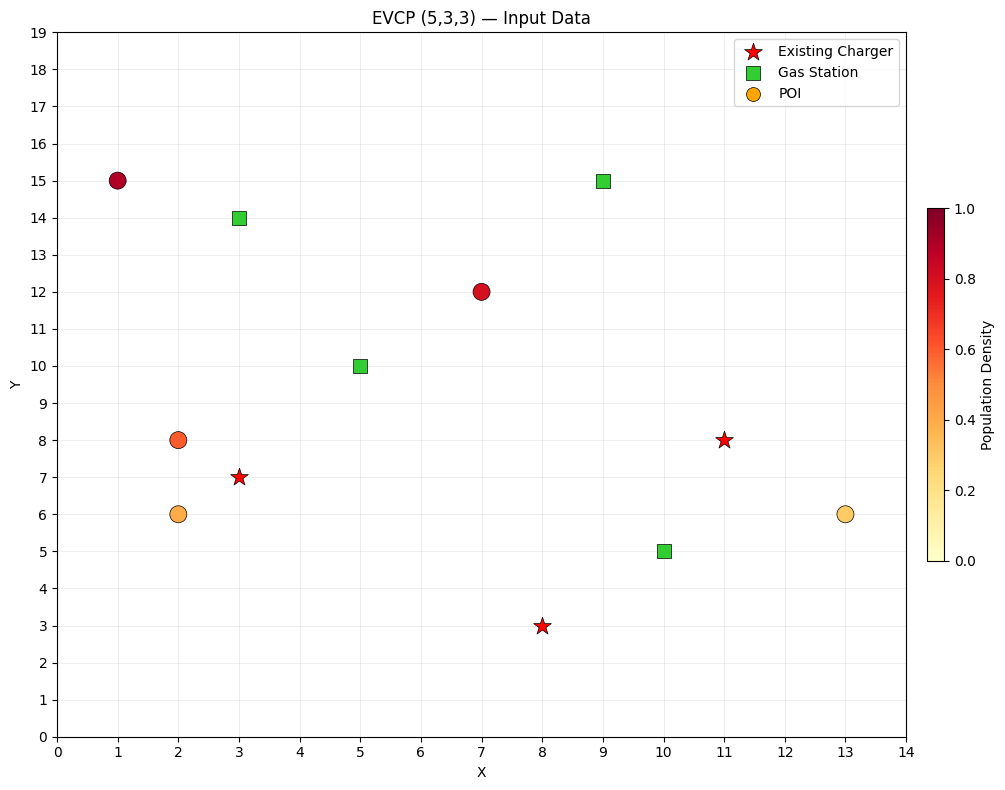

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Input data plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap=cm.YlOrRd, norm=mcolors.Normalize(vmin=0, vmax=1),
    s=150, zorder=5, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.5, label='Population Density')
ex_x, ex_y = zip(*existing_charging_points)
ax.scatter(ex_x, ex_y, color='red', s=180, marker='*', zorder=5,
           edgecolors='black', linewidths=0.5, label='Existing Charger')
gs_x, gs_y = zip(*gas_stations)
ax.scatter(gs_x, gs_y, color='limegreen', s=100, marker='s', zorder=5,
           edgecolors='black', linewidths=0.5, label='Gas Station')
ax.scatter([], [], c='orange', s=100, edgecolors='black', linewidths=0.5, label='POI')
ax.set_xticks(range(0, 15))
ax.set_yticks(range(0, 20))
ax.grid(True, linewidth=0.5, alpha=0.3)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('EVCP (5,3,3) — Input Data')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

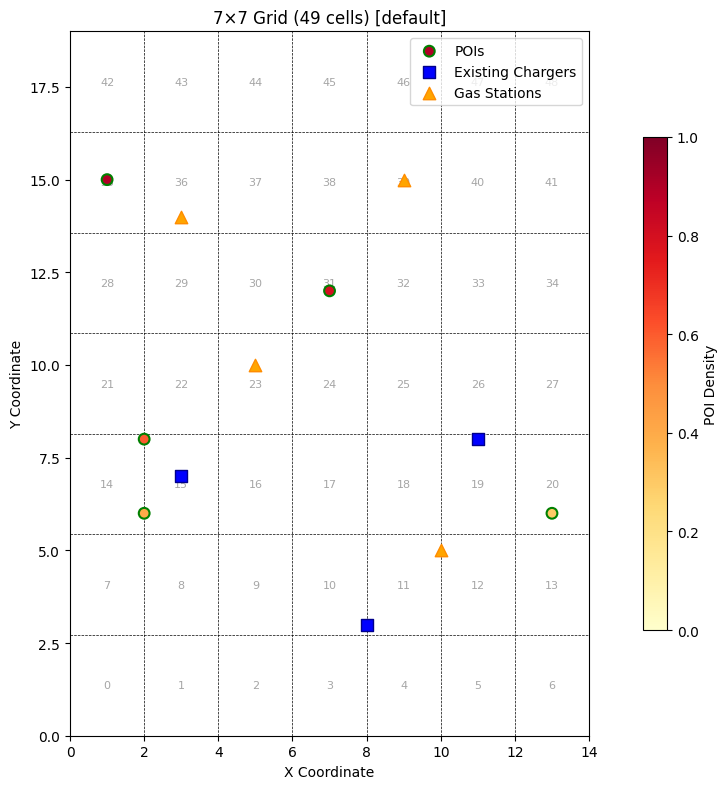

  Grid Info:
    Grid   11 (row=1, col=4): 1 charger(s)
    Grid   12 (row=1, col=5): 1 gas station(s)
    Grid   15 (row=2, col=1): 2 POI(s) [densities: 0.60, 0.40] | 1 charger(s)
    Grid   19 (row=2, col=5): 1 charger(s)
    Grid   20 (row=2, col=6): 1 POI(s) [densities: 0.30]
    Grid   23 (row=3, col=2): 1 gas station(s)
    Grid   31 (row=4, col=3): 1 POI(s) [densities: 0.80]
    Grid   35 (row=5, col=0): 1 POI(s) [densities: 0.90]
    Grid   36 (row=5, col=1): 1 gas station(s)
    Grid   39 (row=5, col=4): 1 gas station(s)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
    grid_details_flag=True,
)

CELL WEIGHT SUMMARY
------------------------  --------
Total cells               49
Cells with POIs           4 (8.2%)
Total aggregated density  3.00
Max weight                5.00
Min non-zero weight       1.50
Total gas stations        4
Total existing chargers   3
------------------------  --------

TOP 8 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
       15      2      1         2    1       1         5             0           1
       35      5      0         1    0.9     0.9       4.5           0           0
       31      4      3         1    0.8     0.8       4             0           0
       20      2      6         1    0.3     0.3       1.5           0           0


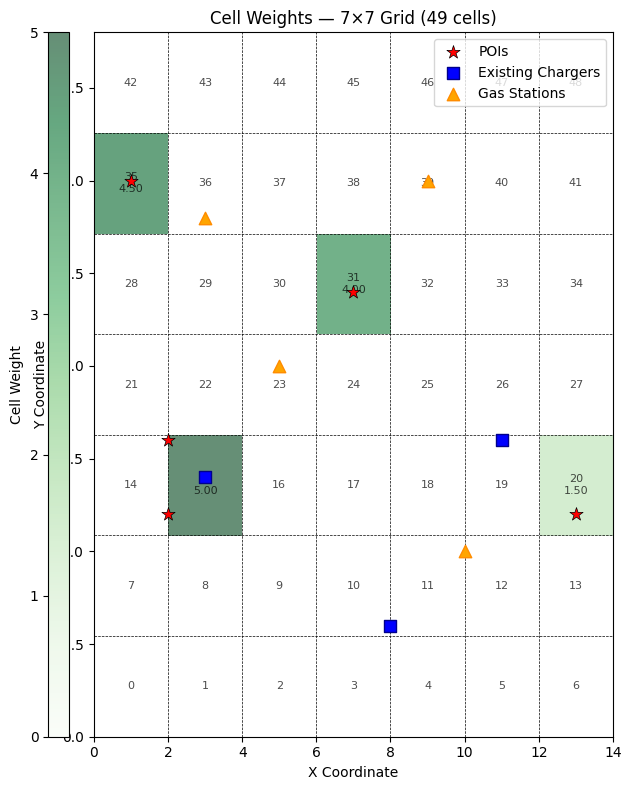

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=8)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=True,
    cell_cmap='Greens', poi_style='solid_red',
)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

r, a, t    = params['radii'], params['alpha'], params['intra']
lambda_val = params['lambda']

SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  2
Rₛ  — service gap radius (matches R₁)           2
R₃  — H3 existing charger penalty radius        1
R₄  — H4 new charger spacing radius             2
R₆  — H6 coverage redundancy radius             1

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]     3
α₂  — H2 gas station bonus                     0.5
α₃  — H3 existing charger penalty              1.32
α₄  — H4 new charger spacing                   1.5
α₅  — H5 constraint  (applied to λ)            1
α₆  — H6 coverage redundancy                   0.6

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existing

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

diag_count    = sum(1 for (i, j) in Q_obj if i == j)
offdiag_count = sum(1 for (i, j) in Q_obj if i != j)
diags['diag_entries']    = diag_count
diags['offdiag_entries'] = offdiag_count

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5b. Post-build calibration — rescale α4/α6 if they dominate diagonal
# ─────────────────────────────────────────────────────────────────────────────
# Flatten all build_qubo parameters into one dict so calibrate_alphas
# can update α4/α6 and we can pass **params_flat directly into rebuild.
params_flat = {
    'alpha1':  a['a1'],
    'alpha2':  a['a2'],
    'alpha3':  a['a3'],
    'alpha4':  a['a4'],
    'alpha5':  a['a5'],
    'alpha6':  a['a6'],
    'beta':    t['beta'],
    'gamma':   t['gamma'],
    'delta':   t['delta'],
    'epsilon': t['epsilon'],
    'lam':     lambda_val,
    'R1':      r['R1'],
    'Rs':      r['Rs'],
    'R3':      r['R3'],
    'R4':      r['R4'],
    'R6':      r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(
    Q_obj, params_flat, diags,
    target_ratio=0.5,   # H4/H6 peaks must not exceed 50% of diagonal peak
    verbose=True,
)

if needs_rebuild:
    print("\nRebuilding Q_obj with calibrated α4/α6...")
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M,
        **params_flat,
    )
    print("Rebuild complete.")
else:
    print("\nNo rebuild needed — Q_obj is already well-calibrated.")

print_qubo_diagnostics(diags, params=params_flat)

CALIBRATE_ALPHAS
  Diagonal peak:  3.0000
  Target (×0.5): 1.5000
  H4 actual peak: 0.7500  ✓ OK
  H6 actual peak: 1.5000  ✓ OK
  → No rebuild needed.

No rebuild needed — Q_obj is already well-calibrated.
QUBO CONSTRUCTION DIAGNOSTICS (Q_obj — H1 through H6, H5 separate)

Grid:  N=49 cells,  m=3 new chargers
  POI cells:            4
  Cells w/ chargers:    3
  Individual chargers:  3  (E_all — counts: {19: 1, 11: 1, 15: 1})
  Radii: R1=2, Rs=2, R3=1, R4=2, R6=1

Call parameters:
  alpha1       = 3.0
  alpha2       = 0.5
  alpha3       = 1.32
  alpha4       = 1.5
  alpha5       = 1.0
  alpha6       = 0.6
  beta         = 1.0
  gamma        = 1.0
  delta        = 1.0
  epsilon      = 1.0
  lam          = 52.5
  R1           = 2
  Rs           = 2
  R3           = 1
  R4           = 2
  R6           = 1

NORMALIZATION SCALES (raw max-abs, divisor applied before α):
  H1 : scale=4.50000  raw range [-4.5000, +0.0000]
  H2 : scale=1.00000  raw range [-1.0000, -0.0000]
  H3 : scale=1.50000 

In [9]:
def plot_Q_matrix(Q_obj, N, title="Q_obj Matrix", clip_percentile=99):
    Q = np.zeros((N, N))
    for (i, j), val in Q_obj.items():
        Q[i, j] = val
        if i != j:
            Q[j, i] = val

    nonzero = Q[Q != 0]
    vmax = np.percentile(np.abs(nonzero), clip_percentile) if len(nonzero) > 0 else 1.0

    plt.figure(figsize=(8, 7))
    plt.imshow(Q, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(label=f'Q value (clipped at {clip_percentile}th pct ± {vmax:.2f})')
    plt.title(title)
    plt.xlabel('Cell j')
    plt.ylabel('Cell i')
    plt.tight_layout()
    plt.show()

    # Plot diagonal only
    diag = np.array([Q_obj.get((i,i), 0.0) for i in range(N)])
    plt.figure(figsize=(10, 2))
    plt.bar(range(N), diag, color=['blue' if v < 0 else 'red' for v in diag])
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("Diagonal of Q_obj (H1+H2+H3 per cell)")
    plt.xlabel("Cell ID")
    plt.ylabel("Q_ii value")
    plt.tight_layout()
    plt.show()

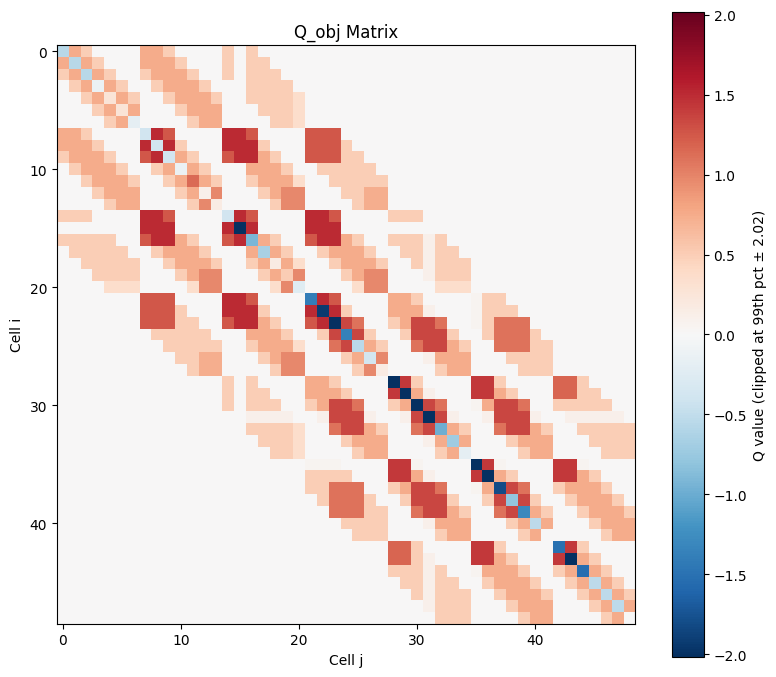

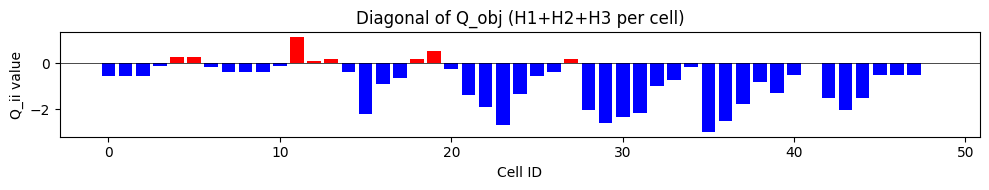

In [10]:
plot_Q_matrix(Q_obj, N_QUBITS)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Brute force on FULL Q (ground truth)
# ─────────────────────────────────────────────────────────────────────────────

top_solutions = brute_force_ranking(Q_obj, N=N_QUBITS, m=M, top_k=10)

print(f"TOP 10 over all C({N_QUBITS},{M})={math.comb(N_QUBITS,M)} combinations:\n")
print(f"{'Rank':<6} {'Score':>10}   {'Grid IDs'}")
print("─" * 45)
for rank, (score, sol) in enumerate(top_solutions, 1):
    print(f"  {rank:<4} {score:>10.4f}   {list(sol)}")

full_optimal_score = top_solutions[0][0]
full_optimal_cells = set(top_solutions[0][1])

TOP 10 over all C(49,3)=18424 combinations:

Rank        Score   Grid IDs
─────────────────────────────────────────────
  1       -7.5056   [15, 30, 35]
  2       -7.3556   [15, 31, 35]
  3       -7.1267   [23, 35, 44]
  4       -6.9500   [15, 35, 37]
  5       -6.9322   [22, 31, 35]
  6       -6.8444   [15, 29, 31]
  7       -6.7889   [15, 31, 36]
  8       -6.6833   [15, 35, 44]
  9       -6.5989   [23, 30, 35]
  10      -6.5556   [15, 24, 35]


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Cell Pruning — reduce QUBO variable count
# ─────────────────────────────────────────────────────────────────────────────
# Three tiers:
#   Tier 1: Remove dead cells (solo=0, far from any competitive cell)
#   Tier 2: Remove cells whose best-case score can't beat a known solution
#   Tier 3: Deduplicate near-identical adjacent cells (heuristic)
#
# Tier 1 & 2 are provably safe (optimal solution preserved).
# Tier 3 is validated empirically against brute force above.

surviving_cells, prune_report = prune_cells(
    Q_obj, N=N_QUBITS, m=M,
    num_cols=plot_deets['num_cols'],
    R4=r['R4'],
    tier3_keep=3,
    verbose=True,
)

# Verify: is the full-Q optimal solution in the surviving set?
optimal_preserved = full_optimal_cells.issubset(set(surviving_cells))
print(f"\nFull-Q optimal {sorted(full_optimal_cells)} in surviving set? "
      f"{'YES' if optimal_preserved else 'NO ← PRUNING BUG'}")

for rank, (score, sol) in enumerate(top_solutions[:5], 1):
    in_set = set(sol).issubset(set(surviving_cells))
    tag = " ✓" if in_set else " ✗"
    print(f"  Rank {rank}: {list(sol)} score={score:.4f}{tag}")

CELL PRUNING
  Starting cells: 49
  Solo scores: 39 negative, 2 zero, 8 positive
  Solo range: [-3.0000, 1.1382]

  Tier 1 (dead cells): 0 pruned, 49 remain  (2 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 36 pruned, 13 remain  (ref score=-7.1267)
  Tier 3 (dedup):      0 pruned, 13 remain  (12 clusters, sizes=[1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1])

  RESULT: 49 → 13 cells (73% reduction)
  Surviving IDs: [15, 22, 23, 28, 29, 30, 31, 35, 36, 37, 42, 43, 44]
  Solo scores: [np.float64(-2.2), np.float64(-1.9267), np.float64(-2.6933), np.float64(-2.0556), np.float64(-2.5889), np.float64(-2.3556), np.float64(-2.1556), np.float64(-3.0), np.float64(-2.5333), np.float64(-1.8), np.float64(-1.5), np.float64(-2.0333), np.float64(-1.5333)]

Full-Q optimal [15, 30, 35] in surviving set? YES
  Rank 1: [15, 30, 35] score=-7.5056 ✓
  Rank 2: [15, 31, 35] score=-7.3556 ✓
  Rank 3: [23, 35, 44] score=-7.1267 ✓
  Rank 4: [15, 35, 37] score=-6.9500 ✓
  Rank 5: [22, 31, 35] score=-6.9322 ✓

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Remap QUBO to reduced variable space
# ─────────────────────────────────────────────────────────────────────────────
# Original cell IDs → contiguous qubit indices 0..K-1
# Q_pruned has the same values as Q_obj, just re-indexed.

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)
K = len(surviving_cells)

print(f"Remapped: {N_QUBITS} cells → {K} qubits")
print(f"  Cell→Qubit mapping: {cell_to_qubit}")
print(f"  Qubit→Cell mapping: {qubit_to_cell}")
print(f"  Q_pruned entries: {len(Q_pruned)}")
print(f"  Search space: C({K},{M}) = {math.comb(K, M)} "
      f"(was C({N_QUBITS},{M}) = {math.comb(N_QUBITS, M)})")

Remapped: 49 cells → 13 qubits
  Cell→Qubit mapping: {15: 0, 22: 1, 23: 2, 28: 3, 29: 4, 30: 5, 31: 6, 35: 7, 36: 8, 37: 9, 42: 10, 43: 11, 44: 12}
  Qubit→Cell mapping: {0: 15, 1: 22, 2: 23, 3: 28, 4: 29, 5: 30, 6: 31, 7: 35, 8: 36, 9: 37, 10: 42, 11: 43, 12: 44}
  Q_pruned entries: 72
  Search space: C(13,3) = 286 (was C(49,3) = 18424)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Brute force on PRUNED Q (validation)
# ─────────────────────────────────────────────────────────────────────────────

pruned_bf = brute_force_ranking(Q_pruned, N=K, m=M, top_k=10)

print(f"TOP solutions on PRUNED Q (K={K}, C({K},{M})={math.comb(K,M)}):\n")
print(f"{'Rank':<6} {'Score':>10}   {'Qubits':<20} {'Original Cells'}")
print("─" * 65)
for rank, (score, sol) in enumerate(pruned_bf, 1):
    cells = sorted([qubit_to_cell[q] for q in sol])
    print(f"  {rank:<4} {score:>10.4f}   {str(list(sol)):<20} {cells}")

pruned_optimal_score = pruned_bf[0][0]
pruned_optimal_cells = sorted([qubit_to_cell[q] for q in pruned_bf[0][1]])

print(f"\n{'─'*65}")
print(f"Full-Q optimal:   score={full_optimal_score:.4f}  cells={sorted(full_optimal_cells)}")
print(f"Pruned-Q optimal: score={pruned_optimal_score:.4f}  cells={pruned_optimal_cells}")
match = abs(full_optimal_score - pruned_optimal_score) < 1e-6
print(f"Score match: {'YES' if match else 'NO ← PROBLEM'}")

TOP solutions on PRUNED Q (K=13, C(13,3)=286):

Rank        Score   Qubits               Original Cells
─────────────────────────────────────────────────────────────────
  1       -7.5056   [0, 5, 7]            [15, 30, 35]
  2       -7.3556   [0, 6, 7]            [15, 31, 35]
  3       -7.1267   [2, 7, 12]           [23, 35, 44]
  4       -6.9500   [0, 7, 9]            [15, 35, 37]
  5       -6.9322   [1, 6, 7]            [22, 31, 35]
  6       -6.8444   [0, 4, 6]            [15, 29, 31]
  7       -6.7889   [0, 6, 8]            [15, 31, 36]
  8       -6.6833   [0, 7, 12]           [15, 35, 44]
  9       -6.5989   [2, 5, 7]            [23, 30, 35]
  10      -6.5389   [6, 7, 12]           [31, 35, 44]

─────────────────────────────────────────────────────────────────
Full-Q optimal:   score=-7.5056  cells=[15, 30, 35]
Pruned-Q optimal: score=-7.5056  cells=[15, 30, 35]
Score match: YES


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Build H5 params for pruned QUBO
# ─────────────────────────────────────────────────────────────────────────────
# H5 constraint (Σx = m) applies over the K pruned variables, not N.
# λ and α5 stay the same — the constraint is the same, just fewer variables.

h5_params_pruned = {
    'lam': h5_params['lam'],
    'alpha5': h5_params['alpha5'],
    'm': M,
}
print(f"H5 params for pruned Q: {h5_params_pruned}")
print(f"QAOA will run on {K} qubits instead of {N_QUBITS}")

H5 params for pruned Q: {'lam': 52.5, 'alpha5': 1.0, 'm': 3}
QAOA will run on 13 qubits instead of 49


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. QAOA — Statevector simulation on PRUNED Q
# ─────────────────────────────────────────────────────────────────────────────
# Using exact statevector (no noise, no shots).
# This is the ideal-case benchmark for the pruned QUBO.

qaoa_results_pruned, qaoa_params = run_qaoa(
    Q_pruned, h5_params_pruned,
    N=K, m=M,
    p=3,
    max_iter=300,
    n_restarts=3,
    seed=42,
    verbose=True,
)

# Translate qubit indices back to original cell IDs
qaoa_results_cells = translate_results(qaoa_results_pruned, qubit_to_cell)

print(f"\n{'─'*80}")
print(f"{'Rank':<6} {'Score':>10} {'Prob':>10}   {'Qubit IDs':<20} {'Cell IDs':<20} {'Positions (r,c)'}")
print("─" * 80)
num_cols = plot_deets['num_cols']
for rank, ((score, qubits, prob), (_, cells, _)) in enumerate(
        zip(qaoa_results_pruned, qaoa_results_cells), 1):
    pos = [(c // num_cols, c % num_cols) for c in cells]
    print(f"  {rank:<4} {score:>10.4f} {prob:>10.6f}   {str(qubits):<20} {str(cells):<20} {pos}")

QAOA Pipeline: N=13, m=3, p=3, restarts=3, max_iter=300, top_k=5
  Cost Hamiltonian: 92 Pauli terms
  Stripped offset: 811.8060  (optimizer sees 91 terms, zero-centered)
  QAOA circuit: 6 parameters (2×p = 2×3), 793 gates after decomposition
  Restart 1/3: cost=-610.0904 (shifted), raw=201.7155, evals=82
  Restart 2/3: cost=-56.6788 (shifted), raw=755.1271, evals=59
  Restart 3/3: cost=-74.2509 (shifted), raw=737.5551, evals=60
  Best shifted cost: -610.0904  (raw: 201.7155)
  Probability on feasible states (popcount=3): 0.1747 (17.5%)
  Unique feasible solutions: 286
  Returning top 5

────────────────────────────────────────────────────────────────────────────────
Rank        Score       Prob   Qubit IDs            Cell IDs             Positions (r,c)
────────────────────────────────────────────────────────────────────────────────
  1       -7.5056   0.000843   [0, 5, 7]            [15, 30, 35]         [(2, 1), (4, 2), (5, 0)]
  2       -7.3556   0.000066   [0, 6, 7]            [15, 

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Final Comparison — Full BF vs Pruned BF vs QAOA
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

# Full brute force
print(f"\n  Full BF (N={N_QUBITS}, C({N_QUBITS},{M})={math.comb(N_QUBITS,M)}):")
print(f"    Optimal: score={full_optimal_score:.4f}  cells={sorted(full_optimal_cells)}")

# Pruned brute force
print(f"\n  Pruned BF (K={K}, C({K},{M})={math.comb(K,M)}):")
print(f"    Optimal: score={pruned_optimal_score:.4f}  cells={pruned_optimal_cells}")
bf_match = abs(full_optimal_score - pruned_optimal_score) < 1e-6
print(f"    Matches full BF: {'YES' if bf_match else 'NO'}")

# QAOA statevector
if qaoa_results_cells:
    qaoa_best_score = qaoa_results_cells[0][0]
    qaoa_best_cells = qaoa_results_cells[0][1]
    qaoa_best_prob  = qaoa_results_cells[0][2]
    print(f"\n  QAOA Statevector (K={K} qubits, p=3):")
    print(f"    Best: score={qaoa_best_score:.4f}  cells={qaoa_best_cells}  "
          f"prob={qaoa_best_prob:.4f}")
    qaoa_match = abs(qaoa_best_score - full_optimal_score) < 1e-6
    print(f"    Matches full BF optimal: {'YES' if qaoa_match else 'NO'}")

    # Check how many of the BF top-5 QAOA found
    bf_top5 = [set(sol) for _, sol in top_solutions[:5]]
    qaoa_found = [set(cells) for _, cells, _ in qaoa_results_cells]
    overlap = sum(1 for s in qaoa_found if s in bf_top5)
    print(f"    BF top-5 found by QAOA: {overlap}/5")

# Resource summary
print(f"\n  RESOURCE SUMMARY:")
print(f"    Qubits: {N_QUBITS} → {K} ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"    Search space: {math.comb(N_QUBITS,M)} → {math.comb(K,M)} "
      f"({100*(1-math.comb(K,M)/math.comb(N_QUBITS,M)):.0f}% reduction)")
print(f"    QAOA Hamiltonian terms: was {N_QUBITS}-qubit, now {K}-qubit")
print(f"    Optimality preserved: {'YES' if bf_match else 'NO'}")
print("=" * 70)

FINAL COMPARISON

  Full BF (N=49, C(49,3)=18424):
    Optimal: score=-7.5056  cells=[15, 30, 35]

  Pruned BF (K=13, C(13,3)=286):
    Optimal: score=-7.5056  cells=[15, 30, 35]
    Matches full BF: YES

  QAOA Statevector (K=13 qubits, p=3):
    Best: score=-7.5056  cells=[15, 30, 35]  prob=0.0008
    Matches full BF optimal: YES
    BF top-5 found by QAOA: 5/5

  RESOURCE SUMMARY:
    Qubits: 49 → 13 (73% reduction)
    Search space: 18424 → 286 (98% reduction)
    QAOA Hamiltonian terms: was 49-qubit, now 13-qubit
    Optimality preserved: YES


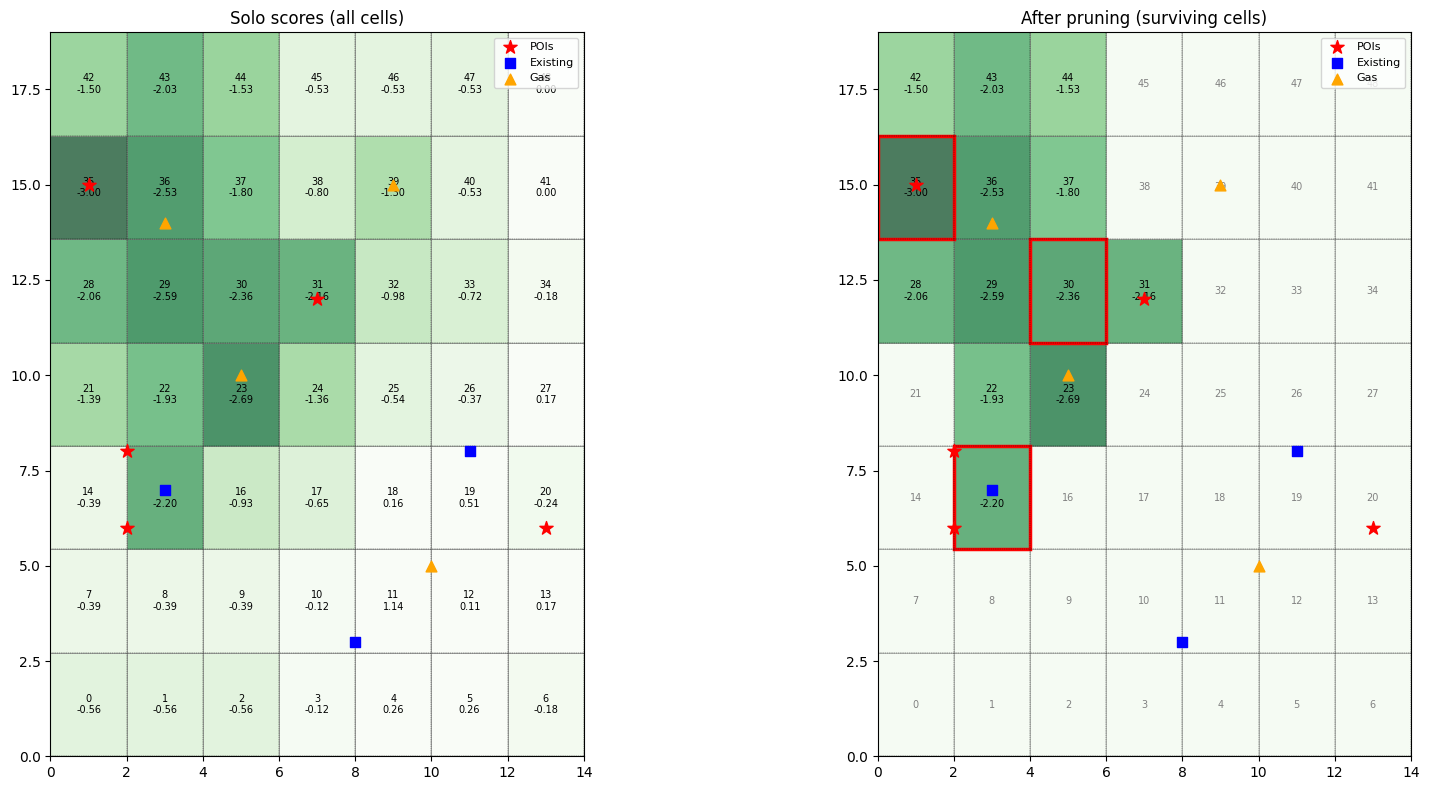

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Visualize pruning on grid
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
solos = compute_solo_scores(Q_obj, N_QUBITS)
num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w = plot_deets['cell_w']
cell_h = plot_deets['cell_h']

for ax_idx, (ax, title, highlight) in enumerate(zip(
    axes,
    ['Solo scores (all cells)', 'After pruning (surviving cells)'],
    [set(range(N_QUBITS)), set(surviving_cells)],
)):
    ax.set_facecolor('white')
    # Draw grid
    for i in range(num_cols + 1):
        ax.axvline(x=X_MIN + i * cell_w, color='black', linestyle='--', linewidth=0.3)
    for j in range(num_rows + 1):
        ax.axhline(y=Y_MIN + j * cell_h, color='black', linestyle='--', linewidth=0.3)

    # Color cells
    for gid, info in grid_details.items():
        cx = (info['x_start'] + info['x_end']) / 2
        cy = (info['y_start'] + info['y_end']) / 2

        if gid in highlight:
            score = solos[gid]
            # Normalize color: most negative = dark green, zero/positive = light
            norm_score = max(0, -score / 3.0)  # 3.0 is ~max magnitude
            color = plt.cm.Greens(min(norm_score, 1.0))
            alpha = 0.7
        else:
            color = plt.cm.Greens(0.12)  # pale green for pruned cells
            alpha = 0.4

        rect = plt.Rectangle(
            (info['x_start'], info['y_start']),
            cell_w, cell_h,
            facecolor=color, alpha=alpha, edgecolor='gray', linewidth=0.5,
        )
        ax.add_patch(rect)

        # Label
        label = f"{gid}"
        if gid in highlight:
            label += f"\n{solos[gid]:.2f}"
        fontsize = 7
        ax.annotate(label, (cx, cy), ha='center', va='center',
                    fontsize=fontsize, color='black' if gid in highlight else 'gray')

    # Mark QAOA best solution
    if ax_idx == 1 and qaoa_results_cells:
        for cell_id in qaoa_results_cells[0][1]:
            info = grid_details[cell_id]
            rect = plt.Rectangle(
                (info['x_start'], info['y_start']),
                cell_w, cell_h,
                facecolor='none', edgecolor='red', linewidth=2.5,
            )
            ax.add_patch(rect)

    # Overlay data points
    if points_of_interest:
        ax.scatter([p[0] for p in points_of_interest],
                   [p[1] for p in points_of_interest],
                   c='red', marker='*', s=100, zorder=5, label='POIs')
    if existing_charging_points:
        ax.scatter(*zip(*existing_charging_points),
                   color='blue', marker='s', s=60, zorder=5, label='Existing')
    if gas_stations:
        ax.scatter(*zip(*gas_stations),
                   color='orange', marker='^', s=60, zorder=5, label='Gas')

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()